In [ ]:
!pip install rasterio

In [1]:
import pickle
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
import matplotlib.pyplot as plt
import rasterio



In [ ]:
# Paths to your raster files
hillshade_path = "Hillshade_1m.tif"
naip_path = "NAIP_1m.tif"
dem_path = "DEM_1m.tif"
road_mask_path = "Roads_Mask.tif"

In [ ]:
stacked_rasters = None

# Step 1: Load hillshade and stack it
with rasterio.open(hillshade_path) as hillshade_dataset:
    hillshade = hillshade_dataset.read(1)  # Read first band (hillshade)

# Stack hillshade array along the last axis (initial stacking)
stacked_rasters = np.stack([hillshade], axis=-1)

# Free up memory for hillshade
del hillshade

# Step 2: Load DEM and add it to the stacked array
with rasterio.open(dem_path) as dem_dataset:
    dem = dem_dataset.read(1)  # Read DEM band (bare earth elevation)

# Concatenate DEM to stacked_rasters along the last axis
stacked_rasters = np.concatenate([stacked_rasters, dem[..., np.newaxis]], axis=-1)

# Free up memory for DEM
del dem

# Step 3: Load NAIP bands (R, G, B, LiDAR) and add to stacked_rasters
with rasterio.open(naip_path) as naip_dataset:
    naip = naip_dataset.read([1, 2, 3, 4])  # Read 4 bands (R, G, B, LiDAR)

# Concatenate NAIP bands to stacked_rasters along the last axis
stacked_rasters = np.concatenate([stacked_rasters, naip[0][..., np.newaxis], 
                                  naip[1][..., np.newaxis], 
                                  naip[2][..., np.newaxis], 
                                  naip[3][..., np.newaxis]], axis=-1)

# Free up memory for NAIP
del naip

# Print the final shape of the stacked raster
print(f"Final stacked shape: {stacked_rasters.shape}")


In [ ]:
with rasterio.open(road_mask_path) as road_mask_dataset:
    road_mask = road_mask_dataset.read(1)  # Read road mask (binary mask)

print(f"road_mask shape: {road_mask.shape}")

In [ ]:
print("Stacked Rasters Shape:", stacked_rasters.shape)

In [3]:

# Check if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

True


In [4]:
class RoadDataset(Dataset):
    def __init__(self, stacked_rasters, road_masks, sector_size=(256, 256)):
        """
        Args:
            stacked_rasters (np.array): The stacked rasters (height, width, channels).
            road_masks (np.array): The road masks (height, width).
            sector_size (tuple): The size of each sector to be extracted (height, width).
        """
        self.stacked_rasters = stacked_rasters  # Shape: (height, width, channels)
        self.road_masks = road_masks  # Shape: (height, width)
        self.sector_size = sector_size  # Tuple (sector_height, sector_width)
        
        # Calculate how many patches we can make based on the image size and patch size
        self.num_patches = self.calculate_num_patches()

    def __len__(self):
        # Since we have one large image, the length of the dataset is the number of patches
        return self.num_patches

    def calculate_num_patches(self):
        """
        Calculates the total number of patches that can be generated from the large image
        based on the patch size.
        
        Returns:
            int: Total number of patches
        """
        height, width, _ = self.stacked_rasters.shape  # Get the dimensions of the raster
        patch_height, patch_width = self.sector_size  # Get the patch dimensions
        
        # Calculate the number of patches that fit in the height and width
        num_patches_height = (height - patch_height) // patch_height + 1
        num_patches_width = (width - patch_width) // patch_width + 1
        
        return num_patches_height * num_patches_width

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the sample to fetch. In this case, it will refer to a specific patch.

        Returns:
            x (torch.Tensor): The input raster image sector as a tensor.
            y (torch.Tensor): The corresponding road mask sector as a tensor.
        """
        # Since we only have one image, idx is used to determine which patch to extract
        raster = self.stacked_rasters  # The single large raster
        mask = self.road_masks  # The corresponding mask for the large image

        # Calculate the position of the patch based on idx
        patch_height, patch_width = self.sector_size
        num_patches_height = (raster.shape[0] - patch_height) // patch_height + 1
        num_patches_width = (raster.shape[1] - patch_width) // patch_width + 1
        
        # Determine the row and column of the patch in the grid of patches
        row = idx // num_patches_width
        col = idx % num_patches_width
        
        # Calculate the coordinates of the top-left corner of the patch
        start_y = row * patch_height
        start_x = col * patch_width
        
        # Extract the patch from the raster and mask
        sector_raster = raster[start_y:start_y+patch_height, start_x:start_x+patch_width, :]
        sector_mask = mask[start_y:start_y+patch_height, start_x:start_x+patch_width]

        # Convert the sector to torch tensors
        x = torch.tensor(sector_raster, dtype=torch.float32)
        y = torch.tensor(sector_mask, dtype=torch.float32)

        return x, y



In [5]:
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(UNetGenerator, self).__init__()
        
        # Encoder (downsampling)
        self.down1 = self.conv_block(in_channels, 64)
        self.down2 = self.conv_block(64, 128)
        self.down3 = self.conv_block(128, 256)
        self.down4 = self.conv_block(256, 512)
        self.down5 = self.conv_block(512, 512)
        self.down6 = self.conv_block(512, 512)
        self.down7 = self.conv_block(512, 512)
        
        # Bottleneck
        self.bottleneck = self.conv_block(512, 512)
        
        # Decoder (upsampling)
        self.up1 = self.upconv_block(512, 512)
        self.up2 = self.upconv_block(512, 512)
        self.up3 = self.upconv_block(512, 512)
        self.up4 = self.upconv_block(512, 256)
        self.up5 = self.upconv_block(256, 128)
        self.up6 = self.upconv_block(128, 64)
        
        # Channel reduction layers for skip connections
        self.reduce_512_1 = nn.Conv2d(1024, 512, kernel_size=1)  # For up1 + down7
        self.reduce_512_2 = nn.Conv2d(1024, 512, kernel_size=1)  # For up2 + down6
        self.reduce_512_3 = nn.Conv2d(1024, 512, kernel_size=1)  # For up3 + down5
        self.reduce_256 = nn.Conv2d(768, 256, kernel_size=1)     # For up4 + down4
        self.reduce_128 = nn.Conv2d(384, 128, kernel_size=1)     # For up5 + down3
        self.reduce_64 = nn.Conv2d(192, 64, kernel_size=1)       # For up6 + down2
        
        # Final convolution (output layer)
        self.final = nn.Conv2d(64, out_channels, kernel_size=3, stride=1, padding=1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
    
    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        down1 = self.down1(x)
        down2 = self.down2(down1)
        down3 = self.down3(down2)
        down4 = self.down4(down3)
        down5 = self.down5(down4)
        down6 = self.down6(down5)
        down7 = self.down7(down6)
        
        # Bottleneck
        bottleneck = self.bottleneck(down7)
        
        # Decoder with skip connections
        up1 = self.up1(bottleneck)
        up1 = torch.cat([up1, down7], dim=1)  # skip connection
        up1 = self.reduce_channels(up1, 512, 1)  # Reduce channels to 512 after concat
        
        up2 = self.up2(up1)
        up2 = torch.cat([up2, down6], dim=1)  # skip connection
        up2 = self.reduce_channels(up2, 512, 2)  # Reduce channels to 512 after concat
        
        up3 = self.up3(up2)
        up3 = torch.cat([up3, down5], dim=1)  # skip connection
        up3 = self.reduce_channels(up3, 512, 3)  # Reduce channels to 512 after concat
        
        up4 = self.up4(up3)
        up4 = torch.cat([up4, down4], dim=1)  # skip connection
        up4 = self.reduce_channels(up4, 256)  # Reduce channels to 256 after concat
        
        up5 = self.up5(up4)
        up5 = torch.cat([up5, down3], dim=1)  # skip connection
        up5 = self.reduce_channels(up5, 128)  # Reduce channels to 128 after concat
        
        up6 = self.up6(up5)
        up6 = torch.cat([up6, down2], dim=1)  # skip connection
        up6 = self.reduce_channels(up6, 64)  # Reduce channels to 64 after concat
        
        # Final layer
        out = self.final(up6)
        return out
    
    def reduce_channels(self, x, target_channels, idx=None):
        # Use the appropriate pre-defined layer based on target channels
        if target_channels == 512:
            if idx == 1:
                return self.reduce_512_1(x)
            elif idx == 2:
                return self.reduce_512_2(x)
            elif idx == 3:
                return self.reduce_512_3(x)
        elif target_channels == 256:
            return self.reduce_256(x)
        elif target_channels == 128:
            return self.reduce_128(x)
        elif target_channels == 64:
            return self.reduce_64(x)
        else:
            raise ValueError(f"No reduction layer defined for target_channels={target_channels}")

In [6]:
stacked_rasters = np.load('stacked_rasters.npy')

print(stacked_rasters.shape)


(13115, 10460, 6)


In [7]:
road_mask = np.load('road_mask.npy')

print(road_mask.shape)


(13115, 10460)


In [8]:
sector_size=(256, 256)
dataset = RoadDataset(stacked_rasters, road_mask, sector_size)

# Print the total number of patches
print(f"Total number of patches: {len(dataset)}")

Total number of patches: 2040


In [9]:
# # Splitting dataset into train and test using sklearn's train_test_split
# train_idx, test_idx = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=42)

# # Create subsets for training and testing
# train_dataset = torch.utils.data.Subset(dataset, train_idx)
# test_dataset = torch.utils.data.Subset(dataset, test_idx)

# del dataset


In [10]:
# Set up DataLoader for batching
batch_size = 32

data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# # Example of iterating over the DataLoader to fetch batches
# for batch_idx, (input_batch, mask_batch) in enumerate(train_loader):
#     print(f"Batch {batch_idx + 1} - Input shape: {input_batch.shape}, Mask shape: {mask_batch.shape}")
#     if batch_idx == 2:  # Only print the first 3 batches as an example
#         break
# Example of iterating over the DataLoader to fetch batches
for batch_idx, (input_batch, mask_batch) in enumerate(data_loader):
    # Reorder input_batch shape to [batch_size, channels, height, width]
    input_batch = input_batch.permute(0, 3, 1, 2)  # Converts [32, 256, 256, 6] -> [32, 6, 256, 256]
    
    # Add channel dimension to mask_batch (if necessary, depending on the network's expectation)
    mask_batch = mask_batch.unsqueeze(1)  # Converts [32, 256, 256] -> [32, 1, 256, 256]
    
    print(f"Batch {batch_idx + 1} - Input shape: {input_batch.shape}, Mask shape: {mask_batch.shape}")
    
    if batch_idx == 2:  # Only print the first 3 batches as an example
        break


Batch 1 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])
Batch 2 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])
Batch 3 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])


In [11]:
def process_image_batch(test_loader, generator):
    generator.eval()  # Set the generator to evaluation mode

    reconstructed_masks = []

    with torch.no_grad():
        for batch in test_loader:
            inputs, masks = batch  # Ensure proper unpacking
            
            # Move tensors to GPU directly
            inputs = inputs.clone().detach().cuda()
            masks = masks.clone().detach().cuda()

            # Ensure proper channel order: [batch, height, width, channels] -> [batch, channels, height, width]
            inputs = inputs.permute(0, 3, 1, 2)  # Permute only if necessary

            # Run inference
            gen_output = generator(inputs)

            # Resize output to match input size
            gen_output = F.interpolate(gen_output, size=(inputs.shape[2], inputs.shape[3]), 
                                       mode='bilinear', align_corners=True)

            # Convert back to CPU numpy array for further processing
            reconstructed_masks.append(gen_output.cpu().numpy())

    return reconstructed_masks


In [12]:
# Load the saved model
generator = UNetGenerator(in_channels=6, out_channels=1)  # 6 input channels (stacked rasters), 1 output channel (road mask)
generator.load_state_dict(torch.load("coen_model_2.pth"))
generator.eval()  # Set to evaluation mode
generator.cuda()  # Move to GPU if available

# Run inference
reconstructed_masks = process_image_batch(data_loader, generator)

# sample_input = torch.randn(1, 6, 256, 256).cuda()  # Assuming the input has 6 channels and the patch size is (256, 256)
# gen_output = generator(sample_input)
# print(f"Generator output shape: {gen_output.shape}")



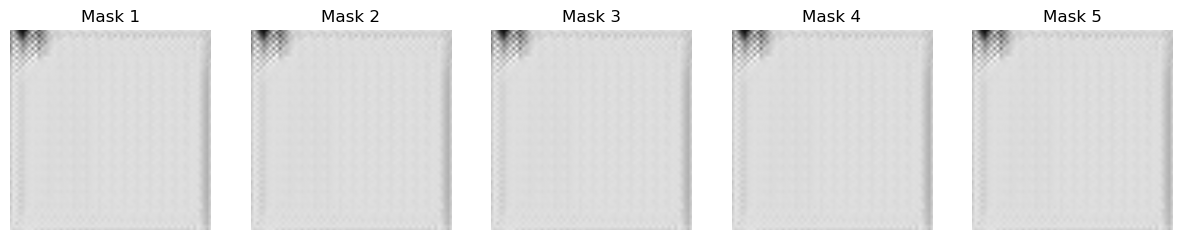

In [13]:
# Convert the list of numpy arrays to a single stacked numpy array
reconstructed_masks = np.vstack(reconstructed_masks)  # Stack along batch dimension

# Plot a few reconstructed masks
num_images = min(5, len(reconstructed_masks))  # Display up to 5 images

fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i in range(num_images):
    axes[i].imshow(reconstructed_masks[i].squeeze(), cmap='gray')  # Squeeze removes extra dimensions
    axes[i].axis("off")  # Hide axes for better visualization
    axes[i].set_title(f"Mask {i+1}")

plt.show()


In [14]:
# def reconstruct_full_mask_by_tiles(generator, test_loader, full_height=13115, full_width=10460, 
#                                  patch_height=256, patch_width=256, batch_size=32,
#                                  tile_size=2000, binary_mode=True, positive_vote_threshold=0.2):
#     """
#     Reconstructs a full-sized mask by processing smaller tiles of the output area.
#     Preserves sparse positive values (like roads) when they appear in multiple patches.
    
#     Args:
#         generator: The model used for predictions
#         test_loader: DataLoader with test patches
#         full_height, full_width: Dimensions of the full output image
#         patch_height, patch_width: Dimensions of each prediction patch
#         batch_size: Batch size used in the test_loader
#         tile_size: Size of each processing tile
#         binary_mode: If True, uses voting system for binary data; otherwise weighted averaging
#         positive_vote_threshold: Threshold for positive voting (only used in binary mode)
#     """
#     import numpy as np
#     import torch
#     import torch.nn.functional as F
#     import gc
    
#     # Initialize final result array
#     full_pred_mask = np.zeros((full_height, full_width))
    
#     # Calculate number of tiles
#     num_tiles_height = (full_height + tile_size - 1) // tile_size
#     num_tiles_width = (full_width + tile_size - 1) // tile_size
#     print(f"Processing {num_tiles_height * num_tiles_width} tiles...")
    
#     # Process each tile
#     for tile_row in range(num_tiles_height):
#         for tile_col in range(num_tiles_width):
#             print(f"Processing tile ({tile_row}, {tile_col})...")
            
#             # Calculate tile boundaries
#             tile_start_y = tile_row * tile_size
#             tile_start_x = tile_col * tile_size
#             tile_end_y = min(tile_start_y + tile_size, full_height)
#             tile_end_x = min(tile_start_x + tile_size, full_width)
#             tile_height = tile_end_y - tile_start_y
#             tile_width = tile_end_x - tile_start_x
            
#             if binary_mode:
#                 # For binary data, we'll use a voting system
#                 # Initialize arrays to track positive votes and total votes
#                 positive_votes = np.zeros((tile_height, tile_width))
#                 total_votes = np.zeros((tile_height, tile_width))
#             else:
#                 # For continuous data, we'll use weighted averaging
#                 tile_sum = np.zeros((tile_height, tile_width))
#                 tile_weights = np.zeros((tile_height, tile_width))
            
#             # Determine which patches overlap with this tile
#             generator.eval()
#             with torch.no_grad():
#                 for idx, (inputs, *_) in enumerate(test_loader):
#                     # Calculate patch position in full image
#                     batch_start_idx = idx * batch_size
#                     current_batch_size = inputs.size(0)
                    
#                     # Process each patch in batch
#                     for b in range(current_batch_size):
#                         batch_idx = batch_start_idx + b
#                         patch_row = batch_idx // ((full_width - patch_width) // patch_width + 1)
#                         patch_col = batch_idx % ((full_width - patch_width) // patch_width + 1)
#                         patch_start_y = patch_row * patch_height
#                         patch_start_x = patch_col * patch_width
#                         patch_end_y = patch_start_y + patch_height
#                         patch_end_x = patch_start_x + patch_width
                        
#                         # Check if this patch overlaps with current tile
#                         if (patch_end_y > tile_start_y and patch_start_y < tile_end_y and 
#                             patch_end_x > tile_start_x and patch_start_x < tile_end_x):
                            
#                             # Process just this patch
#                             patch_input = inputs[b:b+1].cuda()
#                             patch_input = patch_input.permute(0, 3, 1, 2)
                            
#                             # Get prediction
#                             pred = generator(patch_input)
#                             pred_resized = F.interpolate(pred, size=(patch_height, patch_width), 
#                                                       mode='bilinear', align_corners=True)
#                             pred_np = pred_resized[0, 0].cpu().numpy()
                            
#                             # Calculate overlap with tile
#                             overlap_start_y = max(patch_start_y, tile_start_y) - tile_start_y
#                             overlap_start_x = max(patch_start_x, tile_start_x) - tile_start_x
#                             overlap_end_y = min(patch_end_y, tile_end_y) - tile_start_y
#                             overlap_end_x = min(patch_end_x, tile_end_x) - tile_start_x
#                             patch_overlap_start_y = max(tile_start_y, patch_start_y) - patch_start_y
#                             patch_overlap_start_x = max(tile_start_x, patch_start_x) - patch_start_x
#                             patch_overlap_height = overlap_end_y - overlap_start_y
#                             patch_overlap_width = overlap_end_x - overlap_start_x
                            
#                             # Extract the overlapping region from the prediction
#                             patch_region = pred_np[
#                                 patch_overlap_start_y:patch_overlap_start_y+patch_overlap_height, 
#                                 patch_overlap_start_x:patch_overlap_start_x+patch_overlap_width
#                             ]
                            
#                             # Define the tile region
#                             tile_region = slice(overlap_start_y, overlap_end_y), slice(overlap_start_x, overlap_end_x)
                            
#                             if binary_mode:
#                                 # For binary data, count positive values as votes
#                                 # This handles the sparse positive values (like roads)
#                                 positive_votes[tile_region] += (patch_region > 0.5).astype(np.float32)
#                                 total_votes[tile_region] += 1
#                             else:
#                                 # For continuous data, use weighted averaging
#                                 # Create weights - higher weights for positive values
#                                 weights = np.ones_like(patch_region)
#                                 weights[patch_region > 0.5] = 5.0  # Higher weight for positive values
                                
#                                 # Add to tile using weighted sum
#                                 tile_sum[tile_region] += patch_region * weights
#                                 tile_weights[tile_region] += weights
                            
#                             # Free memory
#                             del patch_input, pred, pred_resized
#                             torch.cuda.empty_cache()
            
#             # Finalize the tile
#             if binary_mode:
#                 # Apply threshold to positive votes - any pixel where positive votes
#                 # exceed the threshold percentage of total votes gets a 1
#                 tile_mask = np.zeros((tile_height, tile_width))
#                 valid_votes = total_votes > 0
#                 vote_percentage = np.zeros_like(positive_votes)
#                 vote_percentage[valid_votes] = positive_votes[valid_votes] / total_votes[valid_votes]
#                 tile_mask[vote_percentage >= positive_vote_threshold] = 1.0
                
#                 # Print statistics for this tile
#                 if np.any(valid_votes):
#                     positive_pixels = np.sum(tile_mask > 0)
#                     total_pixels = np.sum(valid_votes)
#                     print(f"Tile positive pixels: {positive_pixels}/{total_pixels} ({positive_pixels/total_pixels*100:.2f}%)")
#                     print(f"Min vote percentage: {np.min(vote_percentage[valid_votes]):.4f}, "
#                           f"Max vote percentage: {np.max(vote_percentage[valid_votes]):.4f}")
#             else:
#                 # Normalize tile using weights
#                 tile_mask = np.zeros_like(tile_sum)
#                 non_zero_weights = tile_weights > 0
#                 tile_mask[non_zero_weights] = tile_sum[non_zero_weights] / tile_weights[non_zero_weights]
            
#             # Copy tile to final result
#             full_pred_mask[tile_start_y:tile_end_y, tile_start_x:tile_end_x] = tile_mask
            
#             # Clear tile data
#             if binary_mode:
#                 del positive_votes, total_votes, tile_mask
#             else:
#                 del tile_sum, tile_weights, tile_mask
#             gc.collect()
    
#     return full_pred_mask

In [15]:
def reconstruct_full_mask_by_tiles(generator, test_loader, full_height=13115, full_width=10460, 
                                 patch_height=256, patch_width=256, batch_size=32,
                                 tile_size=2000, binary_mode=True, positive_vote_threshold=0.2):
    """
    Reconstructs a full-sized mask by processing smaller tiles of the output area.
    Preserves sparse positive values (like roads) when they appear in multiple patches.
    
    Range of values is expected to be around [-0.139172, 0.005209]
    Negative values (≤0) will be considered "not road" (0)
    Positive values (>0) will be considered "road" (1)
    """
    # Initialize final result array
    full_pred_mask = np.zeros((full_height, full_width))
    
    # Calculate number of tiles
    num_tiles_height = (full_height + tile_size - 1) // tile_size
    num_tiles_width = (full_width + tile_size - 1) // tile_size
    print(f"Processing {num_tiles_height * num_tiles_width} tiles...")
    
    # Process each tile
    for tile_row in range(num_tiles_height):
        for tile_col in range(num_tiles_width):
            print(f"Processing tile ({tile_row}, {tile_col})...")
            
            # Calculate tile boundaries
            tile_start_y = tile_row * tile_size
            tile_start_x = tile_col * tile_size
            tile_end_y = min(tile_start_y + tile_size, full_height)
            tile_end_x = min(tile_start_x + tile_size, full_width)
            tile_height = tile_end_y - tile_start_y
            tile_width = tile_end_x - tile_start_x
            
            if binary_mode:
                # For binary data, we'll use a voting system
                # Initialize arrays to track positive votes and total votes
                positive_votes = np.zeros((tile_height, tile_width))
                total_votes = np.zeros((tile_height, tile_width))
            else:
                # For continuous data, we'll use weighted averaging
                tile_sum = np.zeros((tile_height, tile_width))
                tile_weights = np.zeros((tile_height, tile_width))
            
            # Determine which patches overlap with this tile
            generator.eval()
            with torch.no_grad():
                for idx, (inputs, *_) in enumerate(test_loader):
                    # Calculate patch position in full image
                    batch_start_idx = idx * batch_size
                    current_batch_size = inputs.size(0)
                    
                    # Process each patch in batch
                    for b in range(current_batch_size):
                        batch_idx = batch_start_idx + b
                        patch_row = batch_idx // ((full_width - patch_width) // patch_width + 1)
                        patch_col = batch_idx % ((full_width - patch_width) // patch_width + 1)
                        patch_start_y = patch_row * patch_height
                        patch_start_x = patch_col * patch_width
                        patch_end_y = patch_start_y + patch_height
                        patch_end_x = patch_start_x + patch_width
                        
                        # Check if this patch overlaps with current tile
                        if (patch_end_y > tile_start_y and patch_start_y < tile_end_y and 
                            patch_end_x > tile_start_x and patch_start_x < tile_end_x):
                            
                            # Process just this patch
                            patch_input = inputs[b:b+1].cuda()
                            patch_input = patch_input.permute(0, 3, 1, 2)
                            
                            # Get prediction
                            pred = generator(patch_input)
                            pred_resized = F.interpolate(pred, size=(patch_height, patch_width), 
                                                      mode='bilinear', align_corners=True)
                            pred_np = pred_resized[0, 0].cpu().numpy()
                            
                            # Calculate overlap with tile
                            overlap_start_y = max(patch_start_y, tile_start_y) - tile_start_y
                            overlap_start_x = max(patch_start_x, tile_start_x) - tile_start_x
                            overlap_end_y = min(patch_end_y, tile_end_y) - tile_start_y
                            overlap_end_x = min(patch_end_x, tile_end_x) - tile_start_x
                            patch_overlap_start_y = max(tile_start_y, patch_start_y) - patch_start_y
                            patch_overlap_start_x = max(tile_start_x, patch_start_x) - patch_start_x
                            patch_overlap_height = overlap_end_y - overlap_start_y
                            patch_overlap_width = overlap_end_x - overlap_start_x
                            
                            # Extract the overlapping region from the prediction
                            patch_region = pred_np[
                                patch_overlap_start_y:patch_overlap_start_y+patch_overlap_height, 
                                patch_overlap_start_x:patch_overlap_start_x+patch_overlap_width
                            ]
                            
                            # Define the tile region
                            tile_region = slice(overlap_start_y, overlap_end_y), slice(overlap_start_x, overlap_end_x)
                            
                            if binary_mode:
                                # For binary data, count positive values as votes
                                # Using > 0 as threshold instead of > 0.5 since values are in the range [-0.139172, 0.005209]
                                positive_votes[tile_region] += (patch_region > 0).astype(np.float32)
                                total_votes[tile_region] += 1
                            else:
                                # For continuous data, use weighted averaging
                                # Create weights - higher weights for positive values
                                weights = np.ones_like(patch_region)
                                weights[patch_region > 0] = 5.0  # Higher weight for positive values
                                
                                # Add to tile using weighted sum
                                tile_sum[tile_region] += patch_region * weights
                                tile_weights[tile_region] += weights
                            
                            # Free memory
                            del patch_input, pred, pred_resized
                            torch.cuda.empty_cache()
            
            # Finalize the tile
            if binary_mode:
                # Apply threshold to positive votes - any pixel where positive votes
                # exceed the threshold percentage of total votes gets a 1
                tile_mask = np.zeros((tile_height, tile_width))
                valid_votes = total_votes > 0
                vote_percentage = np.zeros_like(positive_votes)
                vote_percentage[valid_votes] = positive_votes[valid_votes] / total_votes[valid_votes]
                tile_mask[vote_percentage >= positive_vote_threshold] = 1.0
                
                # Print statistics for this tile
                if np.any(valid_votes):
                    positive_pixels = np.sum(tile_mask > 0)
                    total_pixels = np.sum(valid_votes)
                    print(f"Tile positive pixels: {positive_pixels}/{total_pixels} ({positive_pixels/total_pixels*100:.2f}%)")
                    print(f"Min vote percentage: {np.min(vote_percentage[valid_votes]):.4f}, "
                          f"Max vote percentage: {np.max(vote_percentage[valid_votes]):.4f}")
            else:
                # Normalize tile using weights
                tile_mask = np.zeros_like(tile_sum)
                non_zero_weights = tile_weights > 0
                tile_mask[non_zero_weights] = tile_sum[non_zero_weights] / tile_weights[non_zero_weights]
                
                # Apply binary thresholding for the final result (> 0 is road)
                tile_mask = (tile_mask > 0).astype(np.float32)
            
            # Copy tile to final result
            full_pred_mask[tile_start_y:tile_end_y, tile_start_x:tile_end_x] = tile_mask
            
            # Clear tile data
            if binary_mode:
                del positive_votes, total_votes, tile_mask
            else:
                del tile_sum, tile_weights, tile_mask
            gc.collect()
    
    return full_pred_mask

In [16]:
import gc
import torch
import torch.nn.functional as F
import numpy as np
from collections import Counter

# Define the analysis function
def analyze_prediction_data(generator, test_loader, sample_size=100, 
                           patch_height=256, patch_width=256, batch_size=32):
    """
    Analyzes the range and distribution of prediction values to determine if they're
    strictly binary (0 and 1) or have floating point values.
    """
    print("Analyzing prediction values...")
    
    # Storage for statistics
    all_values = []
    min_value = float('inf')
    max_value = float('-inf')
    unique_counter = Counter()
    
    # Track binary vs floating point nature
    is_strictly_binary = True
    count_zeros = 0
    count_ones = 0
    count_others = 0
    
    # Sample patches
    generator.eval()
    count = 0
    
    with torch.no_grad():
        for idx, (inputs, *_) in enumerate(test_loader):
            if count >= sample_size:
                break
                
            # Process each patch in batch
            current_batch_size = min(batch_size, inputs.size(0))
            for b in range(current_batch_size):
                if count >= sample_size:
                    break
                
                # Get prediction for this patch
                patch_input = inputs[b:b+1].cuda()
                patch_input = patch_input.permute(0, 3, 1, 2)
                
                # Generate prediction
                pred = generator(patch_input)
                pred_resized = F.interpolate(pred, size=(patch_height, patch_width), 
                                          mode='bilinear', align_corners=True)
                pred_np = pred_resized[0, 0].cpu().numpy()
                
                # Analyze values
                patch_min = np.min(pred_np)
                patch_max = np.max(pred_np)
                min_value = min(min_value, patch_min)
                max_value = max(max_value, patch_max)
                
                # Sample a subset of values (to avoid memory issues)
                sample_indices = np.random.choice(pred_np.size, min(1000, pred_np.size), replace=False)
                sampled_values = pred_np.flatten()[sample_indices]
                all_values.extend(sampled_values.tolist())
                
                # Count zeros, ones, and others
                for val in sampled_values:
                    if abs(val) < 1e-6:  # Approximately zero
                        count_zeros += 1
                    elif abs(val - 1.0) < 1e-6:  # Approximately one
                        count_ones += 1
                    else:
                        count_others += 1
                        is_strictly_binary = False
                
                # Count unique values (rounded to 3 decimal places for floating point)
                rounded_values = np.round(sampled_values, 3)
                unique_counter.update(rounded_values)
                
                # Free memory
                del patch_input, pred, pred_resized
                torch.cuda.empty_cache()
                
                count += 1
                if count % 10 == 0:
                    print(f"Analyzed {count}/{sample_size} patches...")
    
    # Compile results
    total_values = count_zeros + count_ones + count_others
    percent_zeros = (count_zeros / total_values) * 100 if total_values > 0 else 0
    percent_ones = (count_ones / total_values) * 100 if total_values > 0 else 0
    percent_others = (count_others / total_values) * 100 if total_values > 0 else 0
    
    # Get top 10 most common values
    most_common = unique_counter.most_common(10)
    
    print("\n=== Prediction Data Analysis ===")
    print(f"Value Range: [{min_value:.6f}, {max_value:.6f}]")
    print(f"Is Strictly Binary (only 0s and 1s): {is_strictly_binary}")
    print(f"Distribution:")
    print(f"  - Zeros (≈0): {count_zeros} ({percent_zeros:.2f}%)")
    print(f"  - Ones (≈1): {count_ones} ({percent_ones:.2f}%)")
    print(f"  - Others: {count_others} ({percent_others:.2f}%)")
    print(f"Top {len(most_common)} most common values (rounded to 3 decimals):")
    for value, count in most_common:
        print(f"  - {value:.3f}: {count} times ({(count/len(all_values))*100:.2f}%)")
    
    # Calculate variance if there are enough unique values
    if len(unique_counter) > 2:
        variance = np.var(all_values)
        std_dev = np.std(all_values)
        print(f"Variance: {variance:.6f}")
        print(f"Standard Deviation: {std_dev:.6f}")
    
    # Provide recommendation
    if is_strictly_binary:
        print("\nRECOMMENDATION: Your data appears to be strictly binary (0s and 1s).")
        print("You can remove the threshold parameter or set it to a very small value like 0.01.")
    elif percent_zeros + percent_ones > 95:
        print("\nRECOMMENDATION: Your data is predominantly binary with some minor floating point values.")
        print("Consider using a small threshold (e.g., 0.1) to distinguish signal from noise.")
    else:
        print("\nRECOMMENDATION: Your data has significant floating point values.")
        print(f"Consider using a threshold around {min_value + (max_value - min_value) * 0.2:.2f} to separate signal from background.")
    
    return {
        "min_value": min_value,
        "max_value": max_value,
        "is_binary": is_strictly_binary,
        "percent_zeros": percent_zeros,
        "percent_ones": percent_ones,
        "percent_others": percent_others,
        "most_common_values": most_common
    }

In [17]:
def visualize_mask_by_tiles(mask, tile_size=2000, downsampling_factor=8, save_path=None):
    """
    Visualizes a large mask using a tile-based approach to prevent memory issues.
    
    Args:
        mask: The full mask to visualize
        tile_size: Size of tiles to process at once
        downsampling_factor: Factor by which to downsample the image for display
        save_path: Optional path to save the visualization (without extension)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import gc
    from tqdm import tqdm
    
    # Get mask dimensions
    full_height, full_width = mask.shape
    
    # Calculate downsampled dimensions
    downsampled_height = full_height // downsampling_factor
    downsampled_width = full_width // downsampling_factor
    
    # Initialize downsampled mask
    downsampled_mask = np.zeros((downsampled_height, downsampled_width))
    
    # Calculate number of tiles
    num_tiles_height = (full_height + tile_size - 1) // tile_size
    num_tiles_width = (full_width + tile_size - 1) // tile_size
    
    print(f"Processing {num_tiles_height * num_tiles_width} tiles for visualization...")
    
    # Process each tile
    for tile_row in tqdm(range(num_tiles_height)):
        for tile_col in range(num_tiles_width):
            # Calculate tile boundaries for full mask
            tile_start_y = tile_row * tile_size
            tile_start_x = tile_col * tile_size
            tile_end_y = min(tile_start_y + tile_size, full_height)
            tile_end_x = min(tile_start_x + tile_size, full_width)
            
            # Calculate corresponding boundaries in downsampled mask
            ds_start_y = tile_start_y // downsampling_factor
            ds_start_x = tile_start_x // downsampling_factor
            ds_end_y = tile_end_y // downsampling_factor
            ds_end_x = tile_end_x // downsampling_factor
            
            # Extract tile from full mask
            tile = mask[tile_start_y:tile_end_y, tile_start_x:tile_end_x]
            
            # Calculate exact dimensions for this downsampled tile
            ds_height = ds_end_y - ds_start_y
            ds_width = ds_end_x - ds_start_x
            
            # Skip if the tile dimensions are zero
            if ds_height <= 0 or ds_width <= 0:
                continue
                
            # Create buffer for this specific downsampled tile
            downsampled_tile = np.zeros((ds_height, ds_width))
            
            # Calculate how much of the original tile to use for each downsampled pixel
            for i in range(ds_height):
                for j in range(ds_width):
                    # Calculate original pixel ranges
                    y_start = i * downsampling_factor
                    x_start = j * downsampling_factor
                    y_end = min(y_start + downsampling_factor, tile_end_y - tile_start_y)
                    x_end = min(x_start + downsampling_factor, tile_end_x - tile_start_x)
                    
                    # Skip if out of bounds
                    if y_start >= tile.shape[0] or x_start >= tile.shape[1]:
                        continue
                        
                    # Extract and average the patch
                    patch = tile[y_start:y_end, x_start:x_end]
                    if patch.size > 0:  # Check if patch is not empty
                        downsampled_tile[i, j] = np.mean(patch)
            
            # Copy to downsampled result
            downsampled_mask[ds_start_y:ds_end_y, ds_start_x:ds_end_x] = downsampled_tile
            
            # Clean up
            del tile, downsampled_tile
            gc.collect()
    
    # Display the downsampled version
    plt.figure(figsize=(10, 8))
    plt.imshow(downsampled_mask, cmap='gray')
    plt.axis("off")
    plt.title(f"Downsampled Mask (1/{downsampling_factor})")
    
    # Save images if requested
    if save_path is not None:
        # Save just the downsampled version (the full one might be too large)
        plt.imsave(f"{save_path}_downsampled.png", downsampled_mask, cmap='gray')
        print(f"Saved downsampled mask to {save_path}_downsampled.png")
        
        # Optionally save the full mask in a memory-efficient way using PIL
        try:
            from PIL import Image
            import os
            
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
            
            print("Saving full-size mask (this may take some time)...")
            
            # Create a new image
            img = Image.new('L', (full_width, full_height))
            
            # Process by tiles
            for tile_row in tqdm(range(num_tiles_height)):
                for tile_col in range(num_tiles_width):
                    # Calculate tile boundaries
                    tile_start_y = tile_row * tile_size
                    tile_start_x = tile_col * tile_size
                    tile_end_y = min(tile_start_y + tile_size, full_height)
                    tile_end_x = min(tile_start_x + tile_size, full_width)
                    
                    # Skip empty tiles
                    if tile_end_y <= tile_start_y or tile_end_x <= tile_start_x:
                        continue
                    
                    # Extract tile and normalize to 0-255
                    tile = mask[tile_start_y:tile_end_y, tile_start_x:tile_end_x]
                    if np.max(tile) > 1:
                        tile_255 = tile.astype(np.uint8)
                    else:
                        tile_255 = (tile * 255).astype(np.uint8)
                    
                    # Convert to PIL Image
                    tile_img = Image.fromarray(tile_255)
                    
                    # Paste into main image
                    img.paste(tile_img, (tile_start_x, tile_start_y))
                    
                    # Clean up
                    del tile, tile_255, tile_img
                    gc.collect()
            
            # Save full image
            img.save(f"{save_path}_full.png")
            print(f"Saved full mask to {save_path}_full.png")
            
        except Exception as e:
            print(f"Error saving full mask: {e}")
            print("Saving full mask skipped. Try using a smaller region or increasing tile size.")
    
    plt.show()
    
    return downsampled_mask

In [18]:
# First create the model
generator = UNetGenerator(in_channels=6, out_channels=1)
# Then move it to GPU
generator = generator.cuda()
# Clean up memory
# del stacked_rasters
# del road_mask
gc.collect()
torch.cuda.empty_cache()

# First analyze the prediction data to confirm binary nature
analysis = analyze_prediction_data(
    generator=generator,
    test_loader=data_loader,
    sample_size=50,  # Sample 50 patches for analysis
    patch_height=256,
    patch_width=256,
    batch_size=32
)

Analyzing prediction values...
Analyzed 10/50 patches...
Analyzed 20/50 patches...
Analyzed 30/50 patches...
Analyzed 40/50 patches...
Analyzed 50/50 patches...

=== Prediction Data Analysis ===
Value Range: [-0.073152, 0.005462]
Is Strictly Binary (only 0s and 1s): False
Distribution:
  - Zeros (≈0): 0 (0.00%)
  - Ones (≈1): 0 (0.00%)
  - Others: 50000 (100.00%)
Top 10 most common values (rounded to 3 decimals):
  - -0.040: 20699 times (41.40%)
  - -0.039: 13063 times (26.13%)
  - -0.041: 6810 times (13.62%)
  - -0.038: 5857 times (11.71%)
  - -0.037: 1460 times (2.92%)
  - -0.036: 635 times (1.27%)
  - -0.035: 319 times (0.64%)
  - -0.034: 251 times (0.50%)
  - -0.032: 179 times (0.36%)
  - -0.033: 111 times (0.22%)
Variance: 0.000004
Standard Deviation: 0.002008

RECOMMENDATION: Your data has significant floating point values.
Consider using a threshold around -0.06 to separate signal from background.


In [19]:
# Now run the reconstruction using tile-based approach with binary mode
full_mask = reconstruct_full_mask_by_tiles(
    generator=generator,
    test_loader=data_loader,
    full_height=13115, 
    full_width=10460,
    patch_height=256, 
    patch_width=256,
    batch_size=32,
    tile_size=2000,  # Process in 2000x2000 tiles to save memory
    binary_mode=True,  # Use binary voting system
    positive_vote_threshold=0.2  # Any pixel where >=20% of patches vote positive will be positive
)

# Clean up memory again before visualization
gc.collect()
torch.cuda.empty_cache()

Processing 42 tiles...
Processing tile (0, 0)...
Tile positive pixels: 0/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 0.0000
Processing tile (0, 1)...
Tile positive pixels: 0/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 0.0000
Processing tile (0, 2)...
Tile positive pixels: 0/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 0.0000
Processing tile (0, 3)...
Tile positive pixels: 15/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 1.0000
Processing tile (0, 4)...
Tile positive pixels: 271/4000000 (0.01%)
Min vote percentage: 0.0000, Max vote percentage: 1.0000
Processing tile (0, 5)...
Tile positive pixels: 18/480000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 1.0000
Processing tile (1, 0)...
Tile positive pixels: 0/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percentage: 0.0000
Processing tile (1, 1)...
Tile positive pixels: 30/4000000 (0.00%)
Min vote percentage: 0.0000, Max vote percenta

Processing 42 tiles for visualization...


100%|██████████| 7/7 [00:17<00:00,  2.57s/it]


Saved downsampled mask to output/mask_downsampled.png
Saving full-size mask (this may take some time)...


100%|██████████| 7/7 [00:04<00:00,  1.69it/s]


Saved full mask to output/mask_full.png


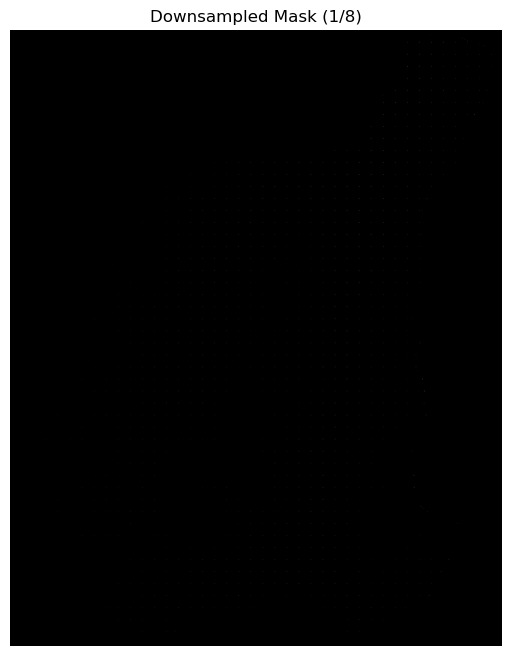

3027

In [20]:
# Visualize the result using tile-based visualization
visualize_mask_by_tiles(
    mask=full_mask, 
    tile_size=2000,          # Process visualization in 2000x2000 chunks
    downsampling_factor=8,   # Display at 1/8 resolution
    save_path="output/mask"  # Save to output/mask_downsampled.png and output/mask_full.png
)

# Optionally, free the mask after visualization if you no longer need it
del full_mask
gc.collect()